(49396, 2)
review       str
sentiment    str
dtype: object
review       0
sentiment    0
dtype: int64
Duplicates: 0
sentiment
negative    24698
positive    24698
Name: count, dtype: int64
count    49396.000000
mean       231.350757
std        171.544594
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: word_count, dtype: float64
Reviews HTML tags: 28853


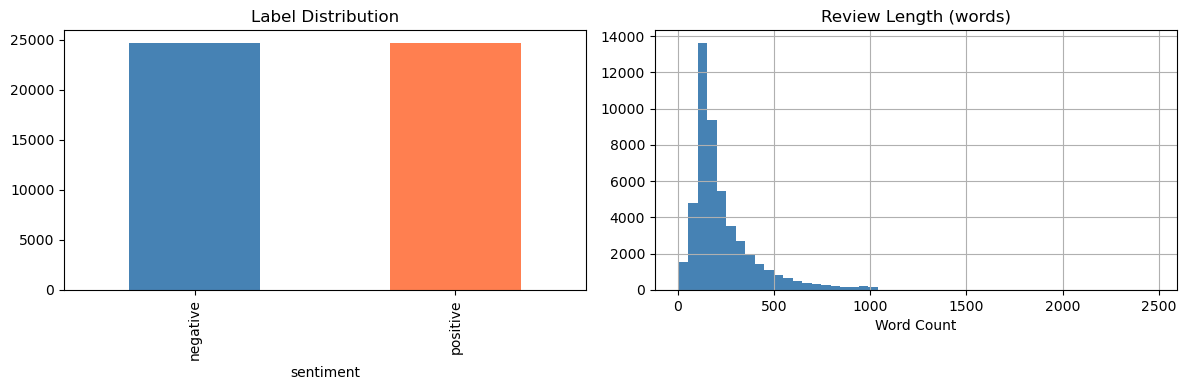

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

df = pd.read_csv("/home/rahma/sentiment-analysis/data/raw/IMDB_Dataset_CLEANED.csv")

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print("Duplicates:", df.duplicated(subset='review').sum())


print(df['sentiment'].value_counts())


df['word_count'] = df['review'].apply(lambda x: len(x.split()))
print(df['word_count'].describe())


has_html = df['review'].str.contains(r'<[^>]+>', regex=True).sum()
print(f"Reviews HTML tags: {has_html}")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))


df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral'])
axes[0].set_title("Label Distribution")

df['word_count'].hist(bins=50, ax=axes[1], color='steelblue')
axes[1].set_title("Review Length (words)")
axes[1].set_xlabel("Word Count")

plt.tight_layout()
plt.show()